In [2]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2025-03-10 08:33:06.815813: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-10 08:33:06.881966: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-10 08:33:06.913296: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741609986.969847     233 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741609986.980760     233 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-10 08:33:07.074938: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [4]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *
from sklearn.decomposition import PCA

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [64]:
myTreatmentColumn = 'both_hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'DeathAtDischarge', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aDropColumns=['Hypothermia', 'treatment_hypothermia', 'treatment_therapy for controlling cerebral perfusion pressure', 
                                                                                         'treatment_neurologic', 'treatment_neuromuscular blocking agent', 'treatment_subcutaneous'], 
                                                                         aSkipTemp = True) 

/home/idies/workspace/Storage/hkim171/ACCM_PMAP_SEPSIS/mbranda1/ttmhte/eICU/eICUUtil.py:6: DtypeWarning: Columns (2059,2070,2081,2083,2084,2089,2095,2099,2108,2119,2130,2132,2133,2138,2144,2148,2305,2307) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [65]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

In [66]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=10)
    myImputer.set_output(transform="pandas")
    myCovariates = getCovariatePreprocessor(['bin__' + myTreatmentColumn])
    myImputer.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer), ('covariates', myCovariates)]

In [67]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [77]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(16, activation='relu'), 
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


In [78]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=10, batch_size=32, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5718 - loss: 0.9072 - roc_auc: 0.5587 - val_accuracy: 0.5721 - val_loss: 0.7123 - val_roc_auc: 0.6883
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6067 - loss: 0.7118 - roc_auc: 0.6745 - val_accuracy: 0.6477 - val_loss: 0.6315 - val_roc_auc: 0.7344
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6720 - loss: 0.6127 - roc_auc: 0.7248 - val_accuracy: 0.6814 - val_loss: 0.6005 - val_roc_auc: 0.7557
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6942 - loss: 0.5757 - roc_auc: 0.7745 - val_accuracy: 0.6930 - val_loss: 0.5813 - val_roc_auc: 0.7711
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7072 - loss: 0.5488 - roc_auc: 0.7884 - val_accuracy: 0.7000 - val_loss: 0.5708 - val_roc_auc: 0.7789
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7458 - loss: 0.5099 - roc_auc: 0.8221 - val_accuracy: 0.7093 - val_loss: 0.5648 - val_roc_auc: 0.7847
Epoc

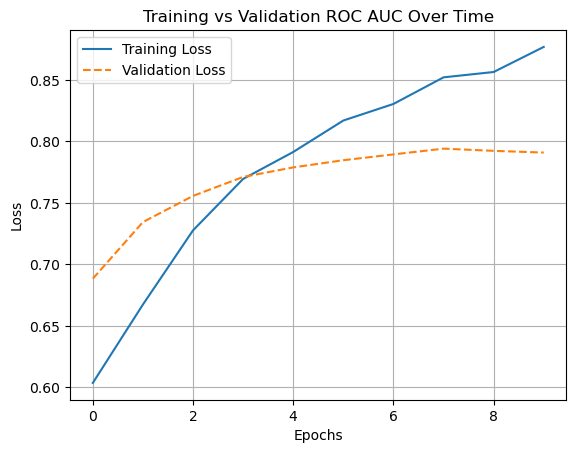

In [79]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [80]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
ROC AUC Score: 0.7909


In [79]:
y_pred_probs.T[0, :]

array([0.84896207, 0.777444  , 0.5945134 , 0.67997634, 0.56610155,
       0.55290836, 0.45225132, 0.7673129 , 0.7527637 , 0.33974695,
       0.34345806, 0.8859349 , 0.9374289 , 0.6233569 , 0.33924007,
       0.39595008, 0.53247297, 0.7617712 , 0.85198355, 0.8452434 ,
       0.8085375 , 0.70392853, 0.89128274, 0.46399885, 0.4717939 ,
       0.26990557, 0.38209486, 0.9167702 , 0.9147049 , 0.9491556 ,
       0.45593897, 0.39345804, 0.9201052 , 0.6874214 , 0.3738942 ,
       0.7068558 , 0.58316344, 0.48190877, 0.46521765, 0.8034461 ,
       0.49828428, 0.58027494, 0.49764276, 0.62510026, 0.7838242 ,
       0.9348261 , 0.55118364, 0.7392547 , 0.82732797, 0.6538673 ,
       0.7946555 , 0.4023672 , 0.6256596 , 0.852084  , 0.746089  ,
       0.54071194, 0.49725232, 0.83459884, 0.7844362 , 0.5190201 ,
       0.6897625 , 0.31997964, 0.72804475, 0.40560013, 0.6981171 ,
       0.4450769 , 0.9485414 , 0.83485574, 0.59692705, 0.73215115,
       0.6750407 , 0.7645294 , 0.60019267, 0.56872654, 0.75670

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step
Optimization terminated successfully.
         Current function value: 0.680748
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.680298
         Iterations 4
Likelihood ratio of test results:
Chi square statistic: 1.8016201105815526
p-value: 0.40624044919403157
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                 2005
Model:                          Logit   Df Residuals:                     2001
Method:                           MLE   Df Model:                            3
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:                0.008036
Time:                        08:56:47   Log-Likelihood:                -1364.9
converged:                       True   LL-Null:                       -1376.0
Covariance Type:  

0.40624044919403157

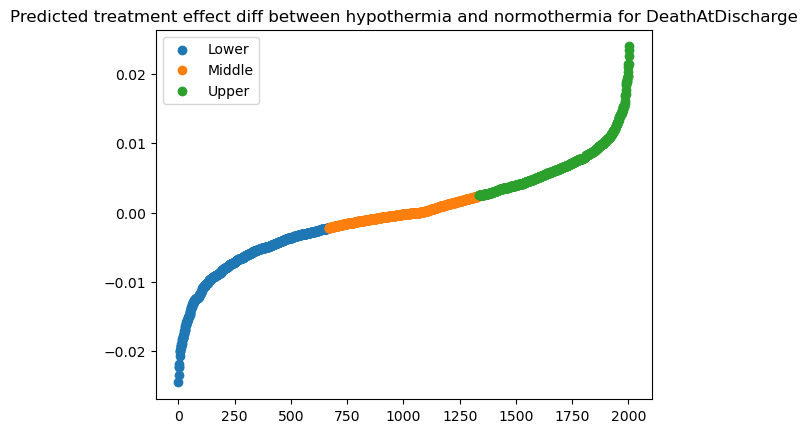

In [85]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'DeathAtDischarge', aGroup = 'keep__bin__both_hypothermia', aUseNeuralNetwork = True, aByGroup = True)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step
Optimization terminated successfully.
         Current function value: 0.681020
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.680220
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.374567027096873
p-value: 0.24102875248990907
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                  860
Model:                          Logit   Df Residuals:                      857
Method:                           MLE   Df Model:                            2
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:                0.007797
Time:                        08:59:45   Log-Likelihood:                -585.68
converged:                       True   LL-Null:                       -590.28
Covariance Type:   

0.24102875248990907

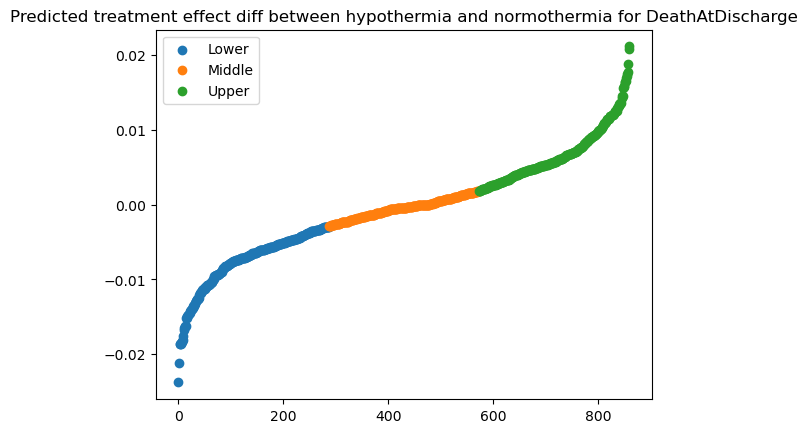

In [90]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'DeathAtDischarge', aGroup = 'keep__bin__both_hypothermia', aUseNeuralNetwork = True, aByGroup = False)

In [87]:
myGroup = myNewDf.groupby(['predicted_effect_group', myTreatment]).agg({myPredicted:'sum', 'index':'count'})
myGroup = myGroup.reset_index()
myGroup['percent'] = myGroup[myPredicted] / myGroup['index']
myGroup
# does not mean anything because you don't know the baseline effect

NameError: name 'myNewDf' is not defined